# RPG Advanced Metadata Mapper

This notebook provides a flexible way to inventory legacy files with different extensions and positional naming conventions.

### Step 1: Configuration
Support for multiple extensions and source directories.

In [1]:
import os
import pandas as pd
from pathlib import Path
from datetime import datetime

SOURCE_DIR = "../data/rpg_source/"
EXTENSIONS = [".rpgle", ".rpg", ".clle", ".sqlrpgle", ".dds"]

### Step 2: Flexible Positional Config
Define **where** the metadata is in the filename. 
- `pos`: 'start', 'end', or a tuple `(start, end)` for substring indexing.
- `len`: length of the segment (required for 'start' and 'end').
- `map`: (Optional) Dictionary to translate codes to business names.

In [2]:
METADATA_CONFIG = {
    "Subsystem": {
        "pos": "start", 
        "len": 3, 
        "map": {
            "ORD": "Orders",
            "INV": "Inventory",
            "GLC": "Finance",
            "SYS": "System"}
    },
    "Module": {
        "pos": (3, 5), # Substring index [3:5]
        "map": {
            "EN": "Entry",
            "WH": "Warehouse",
            "AC": "Accounting",
            "PR": "Reporting"}
    },
    "Program_Type": {
        "pos": "end", 
        "len": 2, 
        "map": {
            "RP": "RPG-ILE",
            "CL": "Control Lang",
            "LF": "Data View"}
    }
}

In [3]:
def extract_segment(name, config):
    """Extracts a segment from the filename based on position config."""
    pos = config.get("pos")
    length = config.get("len", 0)
    
    if pos == "start":
        code = name[:length]
    elif pos == "end":
        code = name[-length:]
    elif isinstance(pos, tuple):
        code = name[pos[0]:pos[1]]
    else:
        code = ""
    
    code = code.strip()
    
    # Apply mapping if available, otherwise return raw code
    mapping = config.get("map", {})
    return mapping.get(code, f"Unknown [{code}]" if code else "N/A")

def analyze_file(file_path):
    name_only = file_path.stem # Filename without extension
    # Pad to 10 for consistency
    name_padded = name_only.ljust(10)
    
    result = {
        "Filename": file_path.name,
        "Ext": file_path.suffix.upper()
    }
    
    for field, config in METADATA_CONFIG.items():
        result[field] = extract_segment(name_padded, config)
        
    return result

# Run the Inventory
files = []
for ext in EXTENSIONS:
    files.extend(Path(SOURCE_DIR).glob(f"*{ext}"))

df = pd.DataFrame([analyze_file(f) for f in files])
df

,Filename,Ext,Subsystem,Module,Program_Type
0,GLACPOSTRP.rpgle,.RPGLE,Unknown [GLA],Unknown [CP],RPG-ILE
1,GLACREPRRP.rpgle,.RPGLE,Unknown [GLA],Unknown [CR],RPG-ILE
2,INVWHSTRRP.rpgle,.RPGLE,Inventory,Warehouse,RPG-ILE
3,ORDENENTRP.rpgle,.RPGLE,Orders,Entry,RPG-ILE
4,ORDENVALRP.rpgle,.RPGLE,Orders,Entry,RPG-ILE
5,ORDPRPRNRP.rpgle,.RPGLE,Orders,Reporting,RPG-ILE
6,SYSTUTLOGRP.rpgle,.RPGLE,System,Unknown [TU],RPG-ILE


### Step 3: Distribution Analysis
Quickly see how your code is distributed across the system.

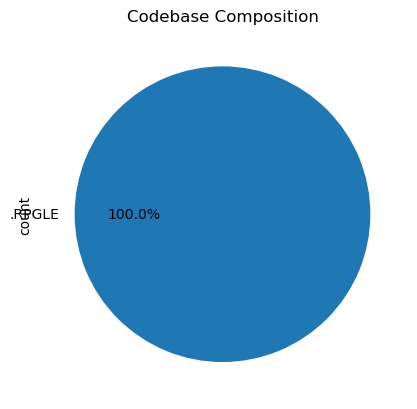

In [4]:
import matplotlib.pyplot as plt

# Breakdown by Extension
df['Ext'].value_counts().plot(kind='pie', title='Codebase Composition', autopct='%1.1f%%')
plt.show()

In [5]:
# Crosstab of Subsystem vs Module
pd.crosstab(df['Subsystem'], df['Module'], margins=True)

Module,Entry,Reporting,Unknown [CP],Unknown [CR],Unknown [TU],Warehouse,All
Subsystem,,,,,,,
Inventory,0,0,0,0,0,1,1
Orders,2,1,0,0,0,0,3
System,0,0,0,0,1,0,1
Unknown [GLA],0,0,1,1,0,0,2
All,2,1,1,1,1,1,7
